                       Zero Mean - EGARCH Model Results                       
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.001
Vol Model:                     EGARCH   Log-Likelihood:               -2553.54
Distribution:                  Normal   AIC:                           5115.08
Method:            Maximum Likelihood   BIC:                           5136.08
                                        No. Observations:                 1409
Date:                Sat, Mar 21 2026   Df Residuals:                     1409
Time:                        13:16:29   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0103  7.145e-03      1.440      0.150 

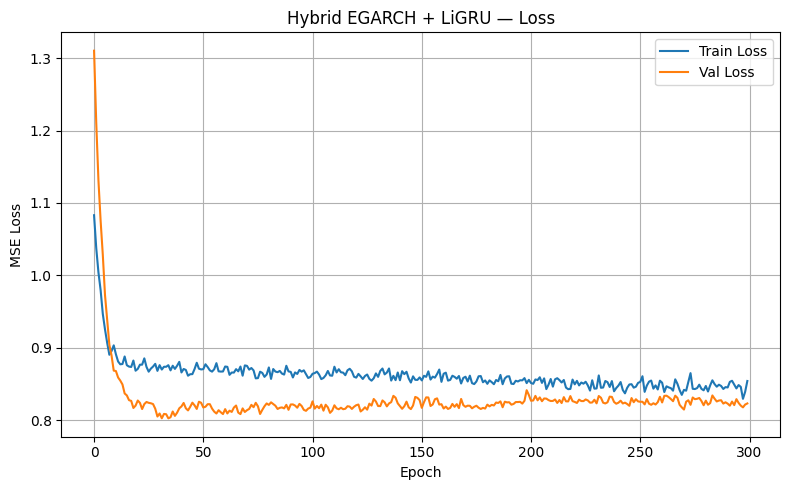


=== How Each Model Handles the Same Data (first 10 test steps) ===
Step    True vol_proxy  EGARCH pred  Hybrid pred  EGARCH err  Hybrid err
0              -9.0770      -9.2740     -10.2903     -0.1970     -1.2133
1             -10.1274      -9.0697     -10.2670      1.0577     -0.1396
2              -8.4704      -9.0218     -10.2446     -0.5515     -1.7743
3             -10.4977      -8.7566     -10.2252      1.7411      0.2725
4              -7.8474      -8.8698     -10.2469     -1.0224     -2.3995
5              -8.6558      -8.5019     -10.2594      0.1538     -1.6036
6              -8.7016      -8.5986     -10.3175      0.1031     -1.6158
7              -9.6765      -8.6930     -10.3777      0.9835     -0.7012
8              -7.4541      -8.7994     -10.3999     -1.3453     -2.9457
9             -10.7773      -8.3452     -10.3286      2.4321      0.4487

=== Final Summary ===
EGARCH alone RMSE:                       2.5986
Hybrid RMSE:                             1.7887
LiGRU impr

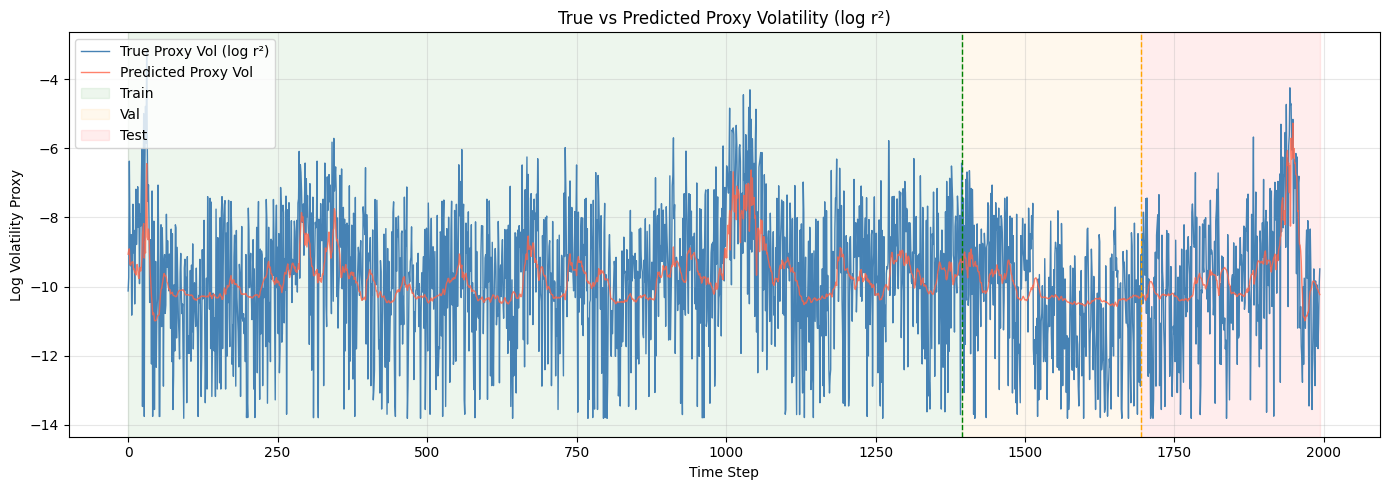

In [3]:
"Experiment code using pytorch api"
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
import torch
import torch.optim as optim
import math

chart1 = pd.read_csv("S&P 500 Historical Data 1987.csv")
chart2 = pd.read_csv("S&P 500 Historical Data 2000-2002.csv")
chart3 = pd.read_csv("S&P 500 Historical Data 2008.csv")
chart4 = pd.read_csv("S&P 500 Historical Data 2020-2022.csv")

chart1['Date'] = pd.to_datetime(chart3['Date'], format='%m/%d/%Y')
month = chart1['Date'].dt.month
month = month.astype(int)

volatility = np.concatenate([
    chart1['Change %'].dropna().values,
    chart2['Change %'].dropna().values,
    chart3['Change %'].dropna().values,
    chart4['Change %'].dropna().values
])

volatility = pd.Series(volatility).str.rstrip('%').astype(float)

returns = volatility.values / 100.0
returns = returns - returns.mean()
returns_scaled = returns * 100
vol_proxy = np.log((returns ** 2) + 1e-6)

def create_sequences(data, target_data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i+seq_length].reshape(-1, 1))  # adds feature dim
        ys.append(target_data[i+seq_length])
    return np.array(xs), np.array(ys)

seq_length = 20

train_split = int(len(returns) * 0.70)

# pip install arch  (if not installed)
from arch import arch_model
import numpy as np
import math
import matplotlib.pyplot as plt

am = arch_model(
    returns_scaled,
    vol='EGARCH',
    p=1, o=1, q=1,    # p=ARCH term, o=asymmetry/leverage, q=GARCH term
    dist='normal',
    mean='Zero'        # demeaned returns, matches your returns = returns - returns.mean()
)

res = am.fit(disp='off', last_obs=train_split)   # fit on train only
print(res.summary())

res_full = am.fix(res.params)   # locks params from train, applies to full series

sigma_egarch_api = res_full.conditional_volatility / 100

egarch_log  = np.log(sigma_egarch_api ** 2 + 1e-6)
vol_proxy   = np.log(returns ** 2 + 1e-6)

min_len     = min(len(egarch_log), len(vol_proxy))
egarch_log  = egarch_log[-min_len:]
vol_proxy_a = vol_proxy[-min_len:]

n         = min_len
train_end = int(n * 0.70)
val_end   = int(n * 0.85)


# scaler_ret = StandardScaler()
# scaler_vol = StandardScaler()
# scaler_target = StandardScaler()
from sklearn.preprocessing import RobustScaler
scaler_ret = RobustScaler()
scaler_vol = RobustScaler()
scaler_target = StandardScaler()

# Fit scalers on training part
scaler_ret.fit(returns[:train_split].reshape(-1, 1))
scaler_vol.fit(sigma_egarch_api[:train_split].reshape(-1, 1))
scaler_target.fit(vol_proxy[:train_split].reshape(-1, 1))

# Transform all data
ret_scaled = scaler_ret.transform(returns.reshape(-1, 1)).flatten()
vol_scaled = scaler_vol.transform(sigma_egarch_api.reshape(-1, 1)).flatten()
target_scaled = scaler_target.transform(vol_proxy.reshape(-1, 1)).flatten()

# 4. Create Sequences (Sliding Window)
def create_multivariate_sequences(ret_data, vol_data, target_data, seq_length):
    xs, ys = [], []
    for i in range(len(ret_data) - seq_length):
        # Input: [Returns, Volatility] at each step
        # Shape: (Seq_Len, 2)
        x_seq = np.column_stack((ret_data[i:i+seq_length], vol_data[i:i+seq_length]))

        # Target: Next step's volatility
        y_val = target_data[i+seq_length]

        xs.append(x_seq)
        ys.append(y_val)
    return np.array(xs), np.array(ys)

SEQ_LENGTH = 20
X, y = create_multivariate_sequences(ret_scaled, vol_scaled, target_scaled, SEQ_LENGTH)
#X, y = create_sequences(ret_scaled, target_scaled, SEQ_LENGTH)

# 5. Split and Convert to Tensor
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = torch.tensor(X[:train_size], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32).unsqueeze(-1)

X_val = torch.tensor(X[train_size:train_size+val_size], dtype=torch.float32)
y_val = torch.tensor(y[train_size:train_size+val_size], dtype=torch.float32).unsqueeze(-1)

X_test = torch.tensor(X[train_size+val_size:], dtype=torch.float32)
y_test = torch.tensor(y[train_size+val_size:], dtype=torch.float32).unsqueeze(-1)

print(f"Input Shape: {X_train.shape}") # Should be (Batch, 20, 2)



# ── Fit EGARCH on training data only (no leakage) ─────────────────────────────
# returns is already defined in your preprocessing
# scale x100 for numerical stability — standard practice with arch library
returns_scaled = returns * 100

train_split = int(len(returns_scaled) * 0.70)
val_split   = int(len(returns_scaled) * 0.85)


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import math

# ── 1. LiGRU Cell (the API) ───────────────────────────────────────────────────
class LiGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.Wz = nn.Linear(input_size, hidden_size)
        self.Uz = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wh = nn.Linear(input_size, hidden_size)
        self.Uh = nn.Linear(hidden_size, hidden_size, bias=False)

    def forward(self, x, h):
        z       = torch.sigmoid(self.Wz(x) + self.Uz(h))
        h_tilde = torch.relu(self.Wh(x) + self.Uh(h))   # ReLU, no reset gate
        return z * h + (1 - z) * h_tilde


class MultiLayerLiGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.cells = nn.ModuleList([
            LiGRUCell(input_dim if i == 0 else hidden_dim, hidden_dim)
            for i in range(num_layers)
        ])
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_dim, 1)

    def forward(self, x, h):
        # x: (batch, seq_len, input_dim)
        # h: (num_layers, batch, hidden_dim)
        h_list  = [h[i] for i in range(self.num_layers)]
        outputs = []
        for t in range(x.size(1)):
            inp = x[:, t, :]
            for i, cell in enumerate(self.cells):
                h_list[i] = cell(inp, h_list[i])
                inp = self.drop(h_list[i]) if i < self.num_layers - 1 else h_list[i]
            outputs.append(self.fc(h_list[-1]))
        output = torch.stack(outputs, dim=1)        # (batch, seq_len, 1)
        h_n    = torch.stack(h_list,  dim=0)        # (num_layers, batch, hidden_dim)
        return output, h_n

input_dim  = 2
hidden_dim = 4
num_layers = 2
dropout    = 0.3
batch_size = 32
num_epochs = 300

model      = MultiLayerLiGRU(input_dim, hidden_dim, num_layers, dropout=0.3)
optimizer  = optim.Adam(model.parameters(), lr=0.001)
criterion  = nn.MSELoss()
train_loader = DataLoader(TensorDataset(X_train, y_train), shuffle=True, batch_size=batch_size)

train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    batch_loss_acc = 0
    for X_batch, y_batch in train_loader:
        h = torch.zeros(num_layers, X_batch.size(0), hidden_dim)
        optimizer.zero_grad()
        out, _ = model(X_batch, h)
        loss   = criterion(out[:, -1, :], y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        batch_loss_acc += loss.item()

    avg_train = batch_loss_acc / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    with torch.no_grad():
        h_val    = torch.zeros(num_layers, X_val.size(0), hidden_dim)
        val_out, _ = model(X_val, h_val)
        val_loss   = criterion(val_out[:, -1, :], y_val).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Train {avg_train:.4f} | Val {val_loss:.4f}")

print(f"\nFinal Train RMSE: {math.sqrt(train_losses[-1]):.4f}")
print(f"Final Val RMSE  : {math.sqrt(val_losses[-1]):.4f}")

# ── 4. Loss curve ─────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Hybrid EGARCH + LiGRU — Loss')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

model.eval()
with torch.no_grad():
    # Get predictions for all splits
    h_train = torch.zeros(num_layers, X_train.size(0), hidden_dim)
    train_out, _ = model(X_train, h_train)
    train_pred = train_out[:, -1, :].numpy()

    h_val = torch.zeros(num_layers, X_val.size(0), hidden_dim)
    val_out, _ = model(X_val, h_val)
    val_pred = val_out[:, -1, :].numpy()

    h_test = torch.zeros(num_layers, X_test.size(0), hidden_dim)
    test_out, _ = model(X_test, h_test)
    test_pred = test_out[:, -1, :].numpy()

# Inverse transform to get back to original log(r^2) scale
train_pred_inv = scaler_target.inverse_transform(train_pred)
val_pred_inv   = scaler_target.inverse_transform(val_pred)
test_pred_inv  = scaler_target.inverse_transform(test_pred)

y_train_inv = scaler_target.inverse_transform(y_train.numpy())
y_val_inv   = scaler_target.inverse_transform(y_val.numpy())
y_test_inv  = scaler_target.inverse_transform(y_test.numpy())

# ADD HERE ↓
# Align EGARCH to test window
egarch_log_full = np.log(sigma_egarch_api ** 2 + 1e-6)
egarch_test     = egarch_log_full[train_size + val_size + SEQ_LENGTH:][:len(y_test_inv)]

print("\n=== How Each Model Handles the Same Data (first 10 test steps) ===")
print(f"{'Step':<6} {'True vol_proxy':>15} {'EGARCH pred':>12} {'Hybrid pred':>12} {'EGARCH err':>11} {'Hybrid err':>11}")
for i in range(10):
    e_err = egarch_test[i] - y_test_inv[i].item()
    h_err = test_pred_inv[i].item() - y_test_inv[i].item()
    print(f"{i:<6} {y_test_inv[i].item():>15.4f} {egarch_test[i]:>12.4f} {test_pred_inv[i].item():>12.4f} {e_err:>11.4f} {h_err:>11.4f}")

egarch_rmse = math.sqrt(np.mean((egarch_test - y_test_inv) ** 2))
hybrid_rmse = math.sqrt(np.mean((test_pred_inv - y_test_inv) ** 2))
egarch_residual  = y_test_inv - egarch_test
ligru_correction = test_pred_inv - egarch_test
corr = np.corrcoef(egarch_residual, ligru_correction)[0, 1]

print(f"\n=== Final Summary ===")
print(f"EGARCH alone RMSE:                       {egarch_rmse:.4f}")
print(f"Hybrid RMSE:                             {hybrid_rmse:.4f}")
print(f"LiGRU improvement:                       {egarch_rmse - hybrid_rmse:.4f} ({100*(egarch_rmse-hybrid_rmse)/egarch_rmse:.1f}% reduction)")
print(f"Corr(EGARCH residual, LiGRU correction): {corr:.4f}")
print("  --> Positive & significant = LiGRU is correcting EGARCH's misses")

print("\n=== Full LiGRU Predictions vs True (first 30 test steps) ===")
print(f"{'Step':<6} {'True':>10} {'Predicted':>12} {'Error':>10} {'Direction':>12}")
for i in range(30):
    true_val = y_test_inv.flatten()[i]
    pred_val = test_pred_inv.flatten()[i]
    err = pred_val - true_val
    # Did model predict the right direction of movement?
    if i > 0:
        true_dir = "UP" if true_val > y_test_inv.flatten()[i-1] else "DOWN"
        pred_dir = "UP" if pred_val > test_pred_inv.flatten()[i-1] else "DOWN"
        direction = "✓" if true_dir == pred_dir else "✗"
    else:
        direction = "-"
    print(f"{i:<6} {true_val:>10.4f} {pred_val:>12.4f} {err:>10.4f} {direction:>12}")

print(f"\n=== Prediction Summary ===")
print(f"True range:      [{y_test_inv.flatten().min():.4f}, {y_test_inv.flatten().max():.4f}]")
print(f"Predicted range: [{test_pred_inv.flatten().min():.4f}, {test_pred_inv.flatten().max():.4f}]")
print(f"True std:        {y_test_inv.flatten().std():.4f}")
print(f"Predicted std:   {test_pred_inv.flatten().std():.4f}")

print(f"\n=== Range Comparison: How Much Each Model Moves ===")
print(f"{'':20} {'Min':>10} {'Max':>10} {'Range':>10} {'Std':>10}")
print(f"{'True vol_proxy':<20} {y_test_inv.flatten().min():>10.4f} {y_test_inv.flatten().max():>10.4f} {y_test_inv.flatten().max()-y_test_inv.flatten().min():>10.4f} {y_test_inv.flatten().std():>10.4f}")
print(f"{'EGARCH pred':<20} {egarch_test.min():>10.4f} {egarch_test.max():>10.4f} {egarch_test.max()-egarch_test.min():>10.4f} {egarch_test.std():>10.4f}")
print(f"{'Hybrid pred':<20} {test_pred_inv.flatten().min():>10.4f} {test_pred_inv.flatten().max():>10.4f} {test_pred_inv.flatten().max()-test_pred_inv.flatten().min():>10.4f} {test_pred_inv.flatten().std():>10.4f}")
print(f"Predicted range: [{test_pred_inv.flatten().min():.4f}, {test_pred_inv.flatten().max():.4f}]")

# Concatenate all splits in order for a full timeline view
all_true = np.concatenate([y_train_inv, y_val_inv, y_test_inv], axis=0).flatten()
all_pred = np.concatenate([train_pred_inv, val_pred_inv, test_pred_inv], axis=0).flatten()

train_end = len(y_train_inv)
val_end   = train_end + len(y_val_inv)

all_true_unlogged = np.exp(all_true)
all_pred_unlogged = np.exp(all_pred)

# --- Plot ---
plt.figure(figsize=(14, 5))
plt.plot(all_true, label='True Proxy Vol (log r²)', color='steelblue', linewidth=1)
plt.plot(all_pred, label='Predicted Proxy Vol',     color='tomato',    linewidth=1, alpha=0.8)

# Shade regions for each split
plt.axvspan(0,          train_end, alpha=0.07, color='green',  label='Train')
plt.axvspan(train_end,  val_end,   alpha=0.07, color='orange', label='Val')
plt.axvspan(val_end,    len(all_true), alpha=0.07, color='red', label='Test')

plt.axvline(train_end, color='green',  linestyle='--', linewidth=1)
plt.axvline(val_end,   color='orange', linestyle='--', linewidth=1)

plt.xlabel('Time Step')
plt.ylabel('Log Volatility Proxy')
plt.title('True vs Predicted Proxy Volatility (log r²)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()